### 数据集

In [124]:
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [125]:
diabetes = load_diabetes()  # 加载糖尿病回归数据集
X = diabetes.data
y = diabetes.target

In [126]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True)

In [127]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor()
reg.fit(X_train, y_train);

In [128]:
reg.score(X_test, y_test)

0.004287744435879537

In [129]:
reg.score(X_train, y_train)

1.0

### 绘制学习曲线

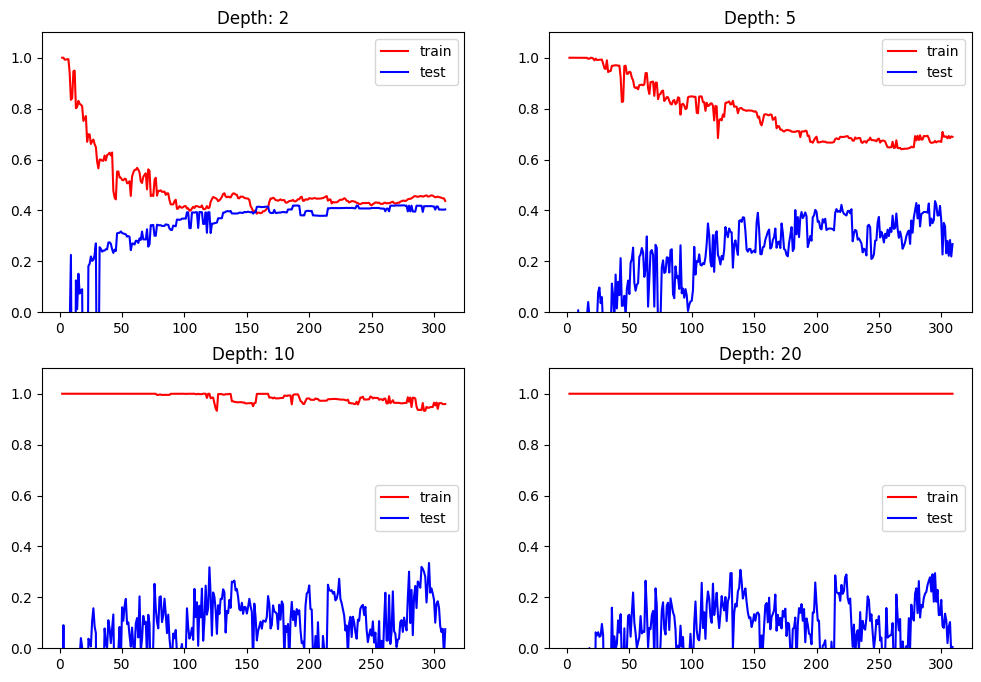

In [130]:
from sklearn.metrics import r2_score
plt.rcParams["figure.figsize"] = (12, 8)  # 设置整张图的大小
max_depth = [2, 5, 10, 20]  # 设置要比较的决策树最大深度
for i, depth in enumerate(max_depth):  # 分别训练不同深度的回归决策树
    reg = DecisionTreeRegressor(max_depth=depth)  # 创建回归决策树模型
    train_score, test_score = [], []  # 用于保存不同训练样本数量下的训练集和测试集 R²
    for k in range(len(X_train)):  # 逐步增加训练样本数量，观察模型性能变化
        reg.fit(X_train[:k + 1], y_train[:k + 1])  # 使用前 k+1 个样本训练模型

        y_train_pred = reg.predict(X_train[:k + 1])  # 预测当前训练数据，并计算训练集 R²
        train_score.append(r2_score(y_train[:k + 1], y_train_pred))

        y_test_pred = reg.predict(X_test)  # 在固定测试集上预测，并计算测试集 R²
        test_score.append(r2_score(y_test, y_test_pred))

    plt.subplot(2, 2, i + 1)  # 创建 2×2 子图，每种 max_depth 对应一个子图
    plt.ylim(0, 1.1)  # 设置纵轴范围
    plt.title("Depth: {0}".format(depth))  # 显示当前决策树最大深度
    plt.plot([k + 1 for k in range(len(X_train))], train_score, color="red", label="train")  # 绘制训练集学习曲线
    plt.plot([k + 1 for k in range(len(X_train))], test_score, color="blue", label="test")  # 绘制测试集学习曲线
    plt.legend()
plt.show()

### 网格搜索最佳参数

In [131]:
from sklearn.model_selection import GridSearchCV
params = {  # 设置需要搜索的超参数范围
    'max_depth': [n for n in range(2, 15)],  # 决策树最大深度：从 2 到 14
    'min_samples_leaf': [sn for sn in range(3, 20)],}  # 叶节点最少样本数：从 3 到 19
grid = GridSearchCV(  # 创建网格搜索对象
    estimator=DecisionTreeRegressor(),  # 使用回归决策树作为基础模型
    param_grid=params,  # 指定要搜索的参数组合
    n_jobs=-1)  # 使用所有 CPU 核心并行计算，提高搜索速度

In [132]:
grid.fit(X_train, y_train);  # 在训练集上进行网格搜索，并通过交叉验证寻找最佳参数

In [133]:
grid.best_params_  # 查看搜索得到的最佳参数组合

{'max_depth': 3, 'min_samples_leaf': 18}

In [134]:
grid.best_score_  # 查看最佳参数对应的平均交叉验证 R²

np.float64(0.3488679314447998)

In [135]:
reg = grid.best_estimator_  # 获取已经使用最佳参数重新训练好的模型

In [136]:
reg.score(X_test, y_test)  # 在测试集上计算最终模型的 R²

0.4234197350930222